# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [ ]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [ ]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [ ]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [ ]:
numbers = list(range(10))

# Двічі ДО set_seed()
print("До set_seed():")
print("randint:", random.randint(1, 100))

numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)

print("randint:", random.randint(1, 100))

numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)


# Фіксуємо seed
set_seed()
print("\nSeed зафіксовано:", SEED)


# Двічі ПІСЛЯ set_seed(), але з повторним set_seed()
print("\nПісля set_seed() з повторним встановленням seed:")

set_seed()
print("randint:", random.randint(1, 100))

set_seed()
print("randint:", random.randint(1, 100))


set_seed()
numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)

set_seed()
numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)


# Двічі БЕЗ проміжного set_seed()
print("\nБез повторного set_seed():")

print("randint:", random.randint(1, 100))
print("randint:", random.randint(1, 100))

numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)

numbers = list(range(10))
random.shuffle(numbers)
print("shuffle:", numbers)

До set_seed():
randint: 84
shuffle: [1, 3, 0, 6, 2, 7, 5, 9, 4, 8]
randint: 9
shuffle: [0, 3, 7, 1, 5, 2, 8, 6, 9, 4]

Seed зафіксовано: 42

Після set_seed() з повторним встановленням seed:
randint: 82
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]

Без повторного set_seed():
randint: 76
randint: 55
shuffle: [5, 3, 2, 8, 4, 6, 7, 1, 9, 0]
shuffle: [5, 1, 9, 0, 2, 4, 7, 3, 6, 8]


Після `set_seed()` генератор випадкових чисел скидається в однаковий початковий стан.
Тому при повторному виклику `set_seed()` перед кожною генерацією результати ідентичні.
Без проміжного `set_seed()` послідовність продовжується — наступні значення вже інші.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [ ]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
# TODO: zeros_arr = np.zeros((3, 4))
# TODO: sevens_arr = np.full((3, 4), 7)
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [ ]:
# TODO: arange_arr = np.arange(0, 20, 2)
# TODO: linspace_arr = np.linspace(0, 1, 5)
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [ ]:
# TODO: identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)
print(identity.ndim)
print(random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[5 1 4]
 [0 9 5]
 [8 0 9]]
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [ ]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [ ]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [ ]:
df = pd.DataFrame({
    "name": ["Оля", "Іван", "Марія", "Петро", "Анна", "Сергій", "Катя", "Дмитро"],
    "score": [92, 78, 85, 67, 95, 74, 88, 81]
})

# відфільтрувати score > 80 і відсортувати за score за спаданням
top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)

     name  score
4    Анна     95
0     Оля     92
6    Катя     88
2   Марія     85
7  Дмитро     81


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [ ]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"
df["grade"] = df["score"].apply(lambda s: "A" if s >= 90 else ("B" if s >= 75 else "C"))
print(df)


     name  score grade
0     Оля     92     A
1    Іван     78     B
2   Марія     85     B
3   Петро     67     C
4    Анна     95     A
5  Сергій     74     C
6    Катя     88     B
7  Дмитро     81     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t)
print(sevens_t)
print("shape zeros:", zeros_t.shape, "dtype:", zeros_t.dtype)
print("shape sevens:", sevens_t.shape, "dtype:", sevens_t.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[7, 7, 7],
        [7, 7, 7]])
shape zeros: torch.Size([2, 3]) dtype: torch.float32
shape sevens: torch.Size([2, 3]) dtype: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [ ]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [ ]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print("shape:", from_list.shape, "dtype:", from_list.dtype, "ndim:", from_list.ndim)
print(random_t)
print("shape:", random_t.shape, "dtype:", random_t.dtype, "ndim:", random_t.ndim)


tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2]) dtype: torch.int64 ndim: 2
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
shape: torch.Size([3, 3]) dtype: torch.float32 ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [ ]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print("Автоматичний градієнт:", x.grad.item())
print("Аналітичний (2*x):", 2 * n)

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
# надрукувати x.grad.item() і порівняти з 2 * n


Автоматичний градієнт: 10.0
Аналітичний (2*x): 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [ ]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")

x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

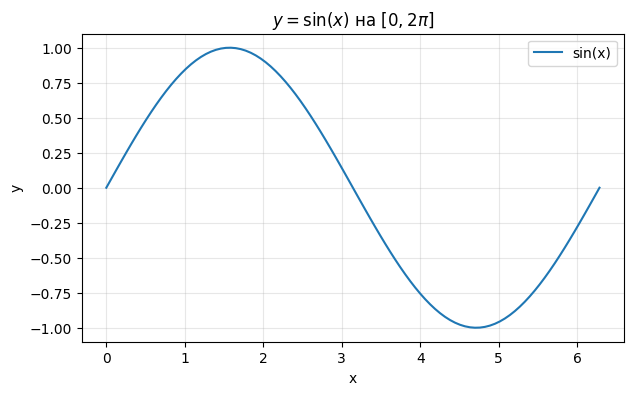

In [ ]:
xs = np.linspace(0, 2 * np.pi, 100)
plt.figure(figsize=(7, 4))
plt.plot(xs, np.sin(xs), label="sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$y = \sin(x)$ на $[0, 2\pi]$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

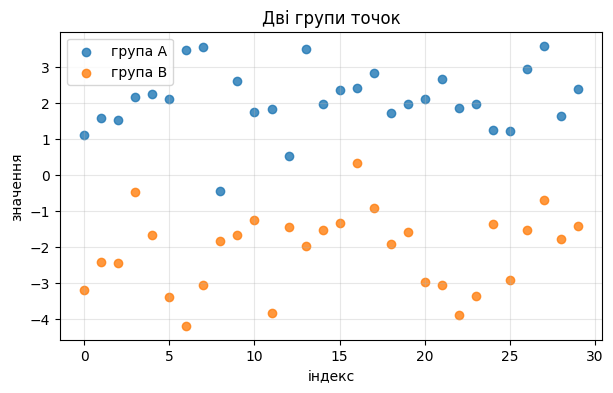

In [ ]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.figure(figsize=(7, 4))
plt.scatter(range(len(group_a)), group_a, color="C0", label="група A", alpha=0.8)
plt.scatter(range(len(group_b)), group_b, color="C1", label="група B", alpha=0.8)
plt.xlabel("індекс")
plt.ylabel("значення")
plt.title("Дві групи точок")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [ ]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

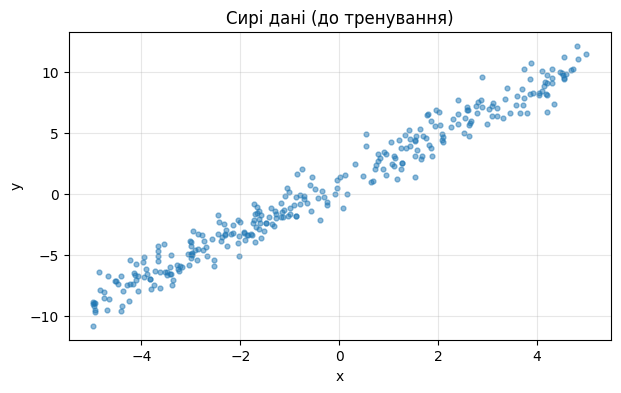

In [ ]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"
plt.figure(figsize=(7, 4))
plt.scatter(x1.numpy(), y1.numpy(), s=12, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Сирі дані (до тренування)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [ ]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...

perm = torch.randperm(TASK1_N)
x1_shuffled = x1[perm]
y1_shuffled = y1[perm]

n_train = int(0.70 * TASK1_N)
n_val = int(0.15 * TASK1_N)

x_train1 = x1_shuffled[:n_train]
y_train1 = y1_shuffled[:n_train]
x_val1   = x1_shuffled[n_train:n_train + n_val]
y_val1   = y1_shuffled[n_train:n_train + n_val]
x_test1  = x1_shuffled[n_train + n_val:]
y_test1  = y1_shuffled[n_train + n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [ ]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


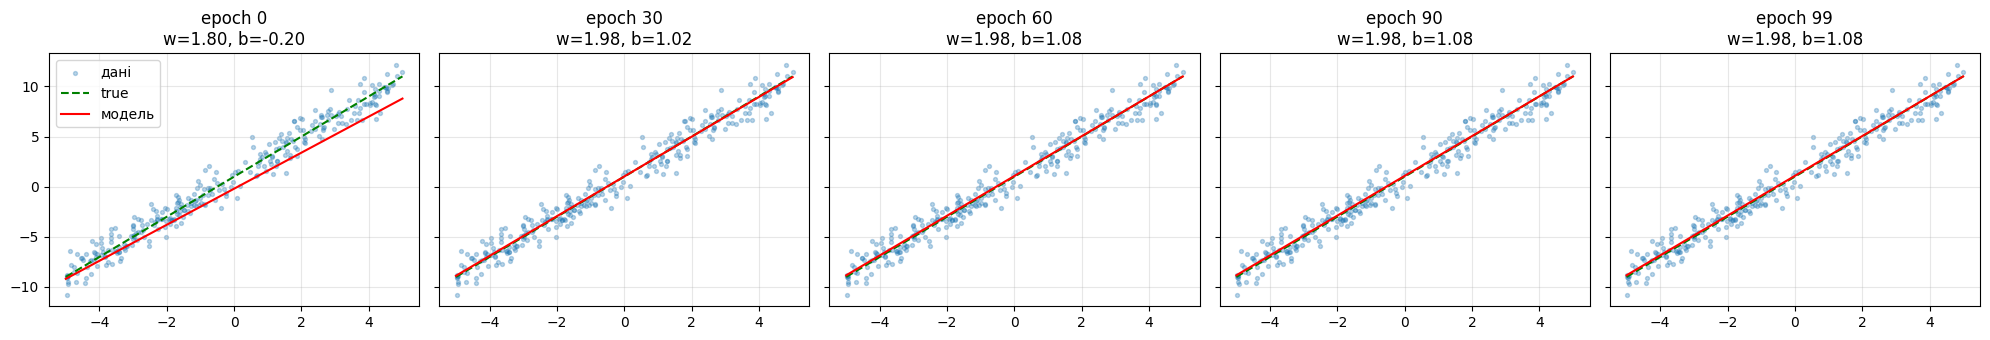

In [ ]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

### Сценарій

**Залежність:** години сну за ніч → продуктивність наступного дня (0–100 балів).

- $w = 8.0$ — кожна додаткова година сну ≈ +8 балів
- $b = 20.0$ — базовий рівень навіть при малому сні

7–8 годин дають ~75–85 балів — правдоподібно. Шум: $\varepsilon \sim \mathcal{N}(0, 5)$.

CSV збережено: /content/drive/MyDrive/ai_systems/lab1/dataset.csv


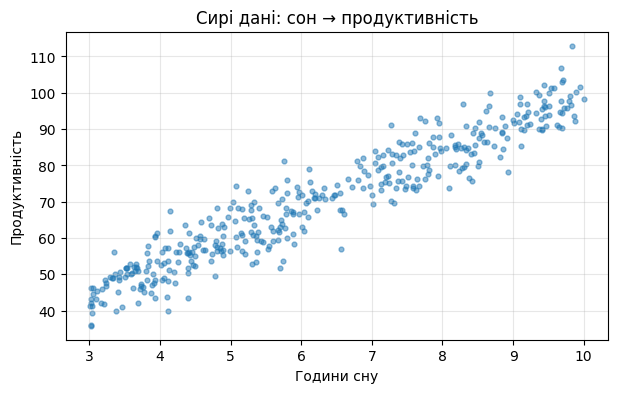

train/val/test: 280/60/60
epoch    0  loss=5666.2554  w=9.3873  b=1.1794
epoch   50  loss=59.9064  w=10.3894  b=3.2733
epoch  100  loss=53.8230  w=10.1413  b=4.9961
epoch  150  loss=48.8731  w=9.9175  b=6.5501
epoch  200  loss=44.8456  w=9.7157  b=7.9519
epoch  250  loss=41.5686  w=9.5336  b=9.2164
epoch  299  loss=38.9503  w=9.3725  b=10.3353
Val  MSE=33.520  MAE=4.512
Test MSE=29.671  MAE=4.642
Справжні: w=8.0, b=20.0
Отримані: w=9.3725, b=10.3353


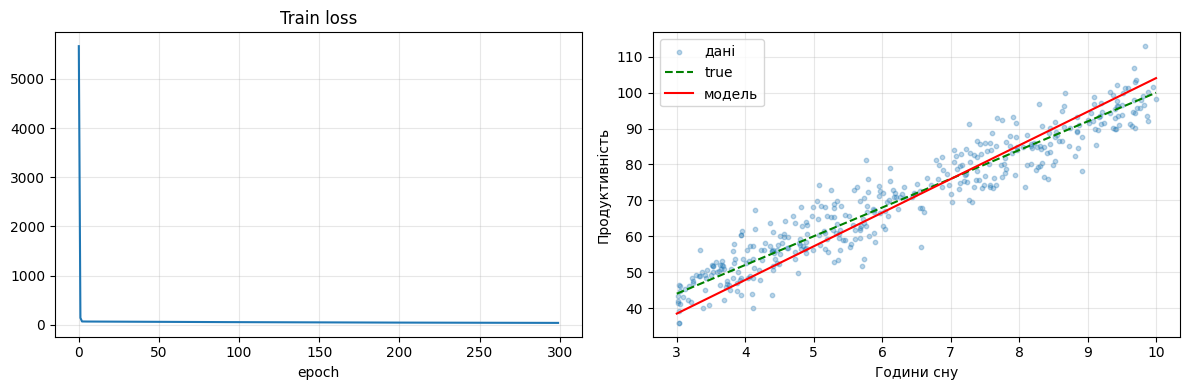

In [ ]:
import csv

set_seed(42)

TRUE_W = 8.0
TRUE_B = 20.0
N = 400
NOISE_STD = 5.0

# Генерація даних
x_sleep = torch.empty(N, 1).uniform_(3.0, 10.0)
noise = NOISE_STD * torch.randn(N, 1)
y_prod = TRUE_W * x_sleep + TRUE_B + noise

# CSV
csv_path = os.path.join(ARTIFACT_DIR, "dataset.csv") if IN_COLAB else "dataset.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["hours_sleep", "productivity"])
    for xi, yi in zip(x_sleep.numpy().flatten(), y_prod.numpy().flatten()):
        writer.writerow([f"{xi:.4f}", f"{yi:.4f}"])
print("CSV збережено:", csv_path)

# Сирі дані
plt.figure(figsize=(7, 4))
plt.scatter(x_sleep.numpy(), y_prod.numpy(), s=12, alpha=0.5)
plt.xlabel("Години сну")
plt.ylabel("Продуктивність")
plt.title("Сирі дані: сон → продуктивність")
plt.grid(alpha=0.3)
plt.show()

# --- Функції ---
def train_val_test_split(x, y, ratios=(0.7, 0.15, 0.15), seed=SEED):
    set_seed(seed)
    n = x.shape[0]
    perm = torch.randperm(n)
    x, y = x[perm], y[perm]
    n_train = int(ratios[0] * n)
    n_val = int(ratios[1] * n)
    return (
        x[:n_train], y[:n_train],
        x[n_train:n_train + n_val], y[n_train:n_train + n_val],
        x[n_train + n_val:], y[n_train + n_val:],
    )

def train_linear_regression(x_train, y_train, lr=0.01, epochs=300, verbose_every=50):
    model = torch.nn.Linear(1, 1)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    history = []
    for epoch in range(epochs):
        opt.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        opt.step()
        history.append(loss.item())
        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(f"epoch {epoch:4d}  loss={loss.item():.4f}  "
                  f"w={model.weight.item():.4f}  b={model.bias.item():.4f}")
    return model, history

def evaluate(model, x, y):
    model.eval()
    with torch.no_grad():
        pred = model(x)
        mse = torch.nn.functional.mse_loss(pred, y).item()
        mae = torch.nn.functional.l1_loss(pred, y).item()
    return mse, mae

# Спліт + тренування
x_tr, y_tr, x_va, y_va, x_te, y_te = train_val_test_split(x_sleep, y_prod)
print(f"train/val/test: {len(x_tr)}/{len(x_va)}/{len(x_te)}")

model, hist = train_linear_regression(x_tr, y_tr, lr=0.01, epochs=300)

mse_val, mae_val = evaluate(model, x_va, y_va)
mse_test, mae_test = evaluate(model, x_te, y_te)
print(f"Val  MSE={mse_val:.3f}  MAE={mae_val:.3f}")
print(f"Test MSE={mse_test:.3f}  MAE={mae_test:.3f}")
print(f"Справжні: w={TRUE_W}, b={TRUE_B}")
print(f"Отримані: w={model.weight.item():.4f}, b={model.bias.item():.4f}")

# Графіки
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist)
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)

x_line = torch.linspace(3, 10, 100).unsqueeze(1)
with torch.no_grad():
    y_line = model(x_line)
axes[1].scatter(x_sleep.numpy(), y_prod.numpy(), s=10, alpha=0.3, label="дані")
axes[1].plot(x_line.numpy(), (TRUE_W * x_line + TRUE_B).numpy(), "g--", label="true")
axes[1].plot(x_line.numpy(), y_line.numpy(), "r-", label="модель")
axes[1].set_xlabel("Години сну")
axes[1].set_ylabel("Продуктивність")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [48]:
torch.save(model.state_dict(), os.path.join(ARTIFACT_DIR, "model.pt"))

**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [ ]:
!pip install -q gradio
import gradio as gr

In [51]:
model = torch.nn.Linear(1, 1)

model.load_state_dict(
    torch.load(os.path.join(ARTIFACT_DIR, "model.pt"))
)

model.eval()

Linear(in_features=1, out_features=1, bias=True)

In [52]:
def predict(hours_sleep):
    x = torch.tensor(
        [[hours_sleep]],
        dtype=torch.float32
    )

    with torch.no_grad():
        return model(x).item()


app = gr.Interface(
    fn=predict,
    inputs=gr.Number(label="Години сну"),
    outputs=gr.Number(label="Прогноз продуктивності"),
    title="Прогноз продуктивності",
    description="Введіть кількість годин сну"
)


app.launch(
    theme=gr.themes.Base(
        primary_hue="blue",
        secondary_hue="gray",
        neutral_hue="gray"
    )
)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://267108dc4213d90dfb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```